In [1]:
import pandas as pd

df = pd.read_csv('diabetes.csv')

In [2]:

import warnings
warnings.filterwarnings('ignore')

In [3]:
df[:5]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:

df.shape

(768, 9)

In [5]:

X = df.drop(columns = ['Outcome'])
y = df['Outcome']


In [6]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [7]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

knn = KNeighborsClassifier()

params_knn = {
    'n_neighbors': np.arange(1, 26),
    'weights': ['uniform', 'distance'],   # equal or weighted by distance
    'metric': ['euclidean', 'manhattan', 'minkowski']  # distance metric
}

In [11]:
params_knn

{'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25]),
 'weights': ['uniform', 'distance'],
 'metric': ['euclidean', 'manhattan', 'minkowski']}

In [12]:

knn_gs = GridSearchCV(knn, params_knn, cv=5)

knn_gs.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25]),
                         'weights': ['uniform', 'distance']})

In [13]:

knn_best = knn_gs.best_estimator_

print("Best KNN params:", knn_gs.best_params_)

Best KNN params: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

params_rf = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [None, 5, 10, 15],          # limit tree depth
    'min_samples_split': [2, 5, 10],          # min samples to split node
    'min_samples_leaf': [1, 2, 4]             # min samples at leaf node
}

rf_gs = GridSearchCV(rf, params_rf, cv=5)
rf_gs.fit(X_train, y_train)

rf_best = rf_gs.best_estimator_
print("Best RF params:", rf_gs.best_params_)

Best RF params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}


In [15]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)

params_log = {
    'C': [0.01, 0.1, 1, 10, 100],         # regularization strength
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'solver': ['lbfgs', 'liblinear', 'saga']  # solvers compatible with penalties
}

log_gs = GridSearchCV(log_reg, params_log, cv=5)
log_gs.fit(X_train, y_train)

log_best = log_gs.best_estimator_
print("Best Logistic Regression params:", log_gs.best_params_)


Best Logistic Regression params: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}


In [16]:
#test the three models with the test data and print their accuracy scores

print('knn: {}'.format(knn_best.score(X_test, y_test)))

print('rf: {}'.format(rf_best.score(X_test, y_test)))

print('log_reg: {}'.format(log_best.score(X_test, y_test)))


knn: 0.7359307359307359
rf: 0.7575757575757576
log_reg: 0.7402597402597403


In [17]:

from sklearn.ensemble import VotingClassifier

#create a dictionary of our models
#estimators=[('knn', knn_best), ('rf', rf_best), ('log_reg', log_reg)]

estimators=[('knn', knn_best), ('rf', rf_best), ('log_reg', log_best)]


In [18]:
estimators

[('knn', KNeighborsClassifier(metric='manhattan', n_neighbors=21)),
 ('rf',
  RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=50,
                         random_state=42)),
 ('log_reg',
  LogisticRegression(C=1, max_iter=1000, penalty='l1', solver='liblinear'))]

In [19]:
#create our voting classifier, inputting our models
#ensemble = VotingClassifier(estimators, voting='hard')

ensemble = VotingClassifier(estimators, voting='hard')


In [20]:

#fit model to training data
ensemble.fit(X_train, y_train)


VotingClassifier(estimators=[('knn',
                              KNeighborsClassifier(metric='manhattan',
                                                   n_neighbors=21)),
                             ('rf',
                              RandomForestClassifier(max_depth=10,
                                                     min_samples_split=5,
                                                     n_estimators=50,
                                                     random_state=42)),
                             ('log_reg',
                              LogisticRegression(C=1, max_iter=1000,
                                                 penalty='l1',
                                                 solver='liblinear'))])

In [21]:
#test our model on the test data
ensemble.score(X_test, y_test)


0.7445887445887446

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = ensemble.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.77      0.87      0.82       150
           1       0.68      0.51      0.58        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.74      0.74      0.73       231



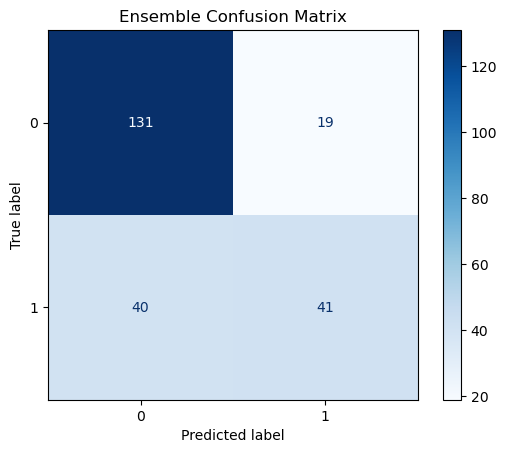

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = ensemble.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Ensemble Confusion Matrix")
plt.show()


In [24]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np

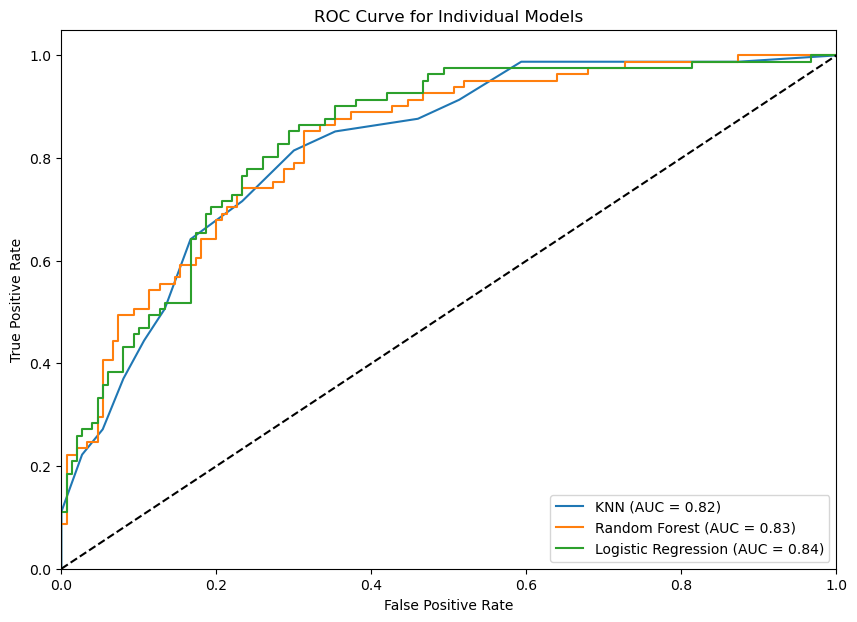

In [25]:
models = {
    'KNN': knn_best,
    'Random Forest': rf_best,
    'Logistic Regression': log_best
}

plt.figure(figsize=(10, 7))

for name, model in models.items():
    # For KNN and RF, use predict_proba[:,1] to get probability of class 1
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # diagonal line for random classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Individual Models')
plt.legend(loc='lower right')
plt.show()
